# Billboard: Top 10 or Not?

**BA780 Team Assignment — Team A05**

Team members: Muhammad Azaan, Omar Tawfik, Caitlin Jeng, Xiaoquan Dai

---

### Research question

Among songs that reached the Billboard Hot 100 between January 2018 and September 2026,
what distinguishes those that climbed into the **Top 10** from those that peaked lower?

### Why this matters

These findings show that a song’s commercial success is driven more by artist history, release strategy, and genre than by measurable lyrical features. This matters because it helps artists, labels, and marketers focus on the factors that are more closely associated with chart performance. It also highlights the importance of careful statistical testing, since apparent patterns can disappear once confounding effects and data leakage are addressed.


### Data sources, access and licensing

| Source | What we used | Access URL | Licence |
|---|---|---|---|
| Billboard Hot 100 weekly archive (mhollingshead) | every weekly chart, 1958-2026 | https://github.com/mhollingshead/billboard-hot-100 | **No licence declared by the repository.** The underlying chart is Billboard's copyrighted compilation |
| LRCLIB | song lyrics | https://lrclib.net/docs | **No licence stated on the public docs page.** Lyrics remain the rights holders' property |
| MusicBrainz | release dates, release type, genres, artist metadata | https://musicbrainz.org/doc/MusicBrainz_API | Core data **CC0 / public domain**; some supplementary data CC-BY-NC-SA |

We checked each source rather than assuming. Only MusicBrainz's licence is explicit.
The other two are used here for **non-commercial academic analysis only**, and neither
the raw lyrics nor the chart archive should be redistributed from this repository.
This is revisited in *Risks and limitations*.

### Reproducibility

Runs top to bottom with **Restart & Run All**. It reads one file with a relative path
(`data/clean/songs_analysis.csv`, shared on the team Drive); in Colab, the first cell asks
you to upload it if it isn't already there. It makes **no API calls** and seeds NumPy at 42.
Data collection lives in `scripts/` (`01_billboard.py` … `08_features.py`) and is not re-run here.

In [ ]:
# Run me first: make sure the data file is in place.
import os

DATA_PATH = "data/clean/songs_analysis.csv"
if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files      # Colab: upload the file once
        files.upload()                      # pick songs_analysis.csv
        os.makedirs("data/clean", exist_ok=True)
        os.replace("songs_analysis.csv", DATA_PATH)
    except ImportError:                     # local Jupyter: the file must already be there
        raise FileNotFoundError(f"Place songs_analysis.csv at {DATA_PATH} (from the team Drive), then re-run.")
print("data file ready:", DATA_PATH)

Saving songs_analysis.csv to songs_analysis.csv


'data/clean/songs_analysis.csv'

In [ ]:
# Setup: load the libraries, set the random seed and chart style, then read the dataset.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Colour-blind safe pair used for every Top 10 / not comparison.
TOP10_COLOUR, OTHER_COLOUR = "#0072B2", "#B0B0B0"

DATA = "data/clean/songs_analysis.csv"
df = pd.read_csv(DATA)
df["top10"] = df["top10"].astype(bool)

print(f"loaded {DATA}: {len(df):,} rows x {len(df.columns)} columns")

loaded data/clean/songs_analysis.csv: 5,342 rows x 71 columns


## Executive summary

We built a dataset of 5,342 songs that entered the Billboard Hot 100 between January 2018 and
September 2026 by joining the weekly chart archive to lyrics (LRCLIB, 99.4% matched) and
release metadata (MusicBrainz, 99.0% matched); 519 of them (9.7%) reached the Top 10.
The strongest signals are not about the song itself: an artist's **past chart record** and
the **way a song is released** matter far more than anything we can measure in its lyrics.
Songs by artists with ten or more previous Top 10 hits reach the Top 10 at 18.5%, against 5.8%
for artists with none, while songs arriving in a five-to-nine track album drop reach it at just
2.1%. Lyric style is close to flat between hits and non-hits, and two apparent findings did not
survive testing: the May/November "hit season" (p = 0.009) disappeared once large album drops
were removed (p = 0.906), and debut position looked perfectly predictive only because debuting
inside the Top 10 already meets the definition of the target.
We therefore recommend treating artist track record and release strategy as the primary
predictors, and treating lyric-derived features as weak unless richer content features are added.


**So what:** who released the song, and how, beats what the song says.

## 1. Problem definition

**Business framing.** A label deciding where to put marketing money wants to know which
songs have a realistic chance of a Top 10 placing, and which levers actually move that
chance. "Make a better song" is not actionable; "release this as a standalone single
rather than as track nine of an album" is.

**Analytical framing.** A binary classification target with a class imbalance:

- **Unit of analysis:** one song, identified by its Billboard title and its debut-week credit.
- **Target:** `top10` — did the song ever reach positions 1-10 during its chart run?
- **Population:** songs whose *first* chart appearance falls on or after 2018-01-01.
  Songs that debuted earlier are excluded even if they charted into the window, so
  every song is observed from the start of its run.
- **Predictors:** everything knowable **at the song's debut week** — the artist's prior
  chart record, genre, lyrics, release metadata, and how many songs the artist put on
  the chart that same week.

**The constraint that shapes everything below.** Every predictor must be knowable at
debut. An artist's history counts only songs that debuted *strictly earlier*; lyrics are
taken from the credit the song debuted under, so a verse added by a later featured
artist cannot leak backwards. Question 10 shows what happens when this discipline slips.

**Two exclusions.**

1. **Songs still on the chart** (`in_model == False`) have no final peak, so no reliable
   label. They stay in the file for description but are dropped from every test.
2. **2025-2026 songs** are held out as a test set. All hypothesis testing below runs on
   the 2018-2024 training years, so the choices we make here cannot quietly overfit the
   data a future model will be judged on.

   **Success criteria.** This phase succeeds if it delivers two things: a clean, documented dataset of every 2018–2026 Hot 100 song with only debut-week predictors, and a ranked list of the factors that genuinely separate Top 10 hits from lower-peaking songs. We count a factor as meaningful only if the difference is statistically significant (p < 0.05) **and** at least a small effect (Cramér's V ≥ 0.1), since with thousands of songs even trivial differences can pass a significance test. In the final phase, success means a prediction model trained on 2018–2024 that identifies Top 10 hits in the held-out 2025–2026 songs better than a simple baseline using artist history alone, judged by precision and recall rather than accuracy.

In [ ]:
# Split songs into training years (2018-2024) and held-out test years (2025-2026).
# Every test below uses the training years only.
train = df[df["model_split"] == "train"].copy()
test = df[df["model_split"] == "test"].copy()
excluded = df[~df["in_model"]]

print(f"all songs          {len(df):>6,}")
print(f"  train 2018-2024  {len(train):>6,}   Top 10: {train['top10'].sum():>4} ({train['top10'].mean()*100:.1f}%)")
print(f"  test  2025-2026  {len(test):>6,}   held out, untouched below")
print(f"  no final peak    {len(excluded):>6,}   still charting, dropped from all tests")

all songs           5,342
  train 2018-2024   4,293   Top 10:  441 (10.3%)
  test  2025-2026     950   held out, untouched below
  no final peak        99   still charting, dropped from all tests


**So what:** we are predicting a 1-in-10 event, using only what a label would know on release week.

## 2. Data description

Three sources, joined on the song's debut-week credit.

| Source | Grain | Rows retrieved | Matched |
|---|---|---|---|
| Billboard weekly archive | one row per song per chart week | 3,555 weekly charts, 1958-2026 | n/a (this is the spine) |
| LRCLIB | one row per song | 5,377 fetched | **99.4%** at or above the match threshold |
| MusicBrainz | one recording + its artists per song | 5,349 songs, 1,269 artists | **99.0%** |

The archive reaches back to 1958 even though the study window starts in 2018, because
an artist's *prior* record has to be counted from the whole of chart history. Drake's
"prior entries" figure is meaningless if we only look back to 2018.

Matching to LRCLIB and MusicBrainz is fuzzy, so every match carries a confidence score
(0-100) and the search that found it. We treat 72+ as trusted; below that the row keeps
its data for inspection but is not counted as matched.

In [ ]:
# Overview of the dataset: column types and summary statistics for the key columns.
print("Shape and dtypes\n" + "-" * 60)
df.info(max_cols=0, memory_usage=True)

key = ["top10", "peak_position", "weeks_on_chart", "debut_position",
       "prior_top10s", "prior_entries", "word_count", "unique_word_ratio",
       "same_artist_debuts_that_week"]
print("\n\nNumeric summary of the key columns\n" + "-" * 60)
display(df[key].describe().T.round(3))

Shape and dtypes
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5342 entries, 0 to 5341
Columns: 71 entries, title to model_split
dtypes: bool(16), float64(11), int64(15), object(29)
memory usage: 2.3+ MB


Numeric summary of the key columns
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
peak_position,5342.0,51.168,28.402,1.000,27.000,53.000,75.000,100.000
weeks_on_chart,5342.0,8.180,11.168,1.000,1.000,2.000,12.000,112.000
debut_position,5342.0,60.530,29.139,1.000,38.000,65.000,87.000,100.000
prior_top10s,5342.0,7.228,13.409,0.000,0.000,2.000,8.000,80.000
prior_entries,5342.0,45.133,64.859,0.000,5.000,20.000,58.000,362.000
word_count,5310.0,447.505,193.845,7.000,310.000,410.000,555.000,1711.000
unique_word_ratio,5310.0,0.364,0.085,0.071,0.308,0.359,0.414,0.903
same_artist_debuts_that_week,5342.0,6.995,7.942,1.000,1.000,2.000,12.000,40.000


In [ ]:
# How many songs reached the Top 10, overall and per debut year.
print("Target balance")
counts = df["top10"].value_counts()
for label, n in counts.items():
    print(f"  {'Top 10' if label else 'peaked 11-100':<15} {n:>5,}  ({n/len(df)*100:.1f}%)")

print("\nSongs per debut year")
display(
    df.groupby("debut_year")
      .agg(songs=("title", "size"), top10=("top10", "sum"))
      .assign(top10_rate_pct=lambda t: (t["top10"] / t["songs"] * 100).round(1))
)

Target balance
  peaked 11-100   4,823  (90.3%)
  Top 10            519  (9.7%)

Songs per debut year


,songs,top10,top10_rate_pct
debut_year,,,
2018,595,67,11.3
2019,518,48,9.3
2020,674,65,9.6
2021,647,63,9.7
2022,629,77,12.2
2023,613,58,9.5
2024,617,63,10.2
2025,570,49,8.6
2026,479,29,6.1


**So what:** the target is stable at roughly one in ten across all nine years, so no year dominates the signal.

## 3. Data cleaning

Cleaning was done by the pipeline in `scripts/`, not in this notebook, so the notebook
stays reproducible without API access. This section documents what was changed and shows
the evidence.

### 3.1 What we changed and why

| Column | Issue | Action | Justification |
|---|---|---|---|
| `artist` | Billboard writes one credit as a single string, and `&` / `,` separators were not being split at all because the regex used `\b&\b`, which can never match — a word boundary needs a word character on one side | Rewrote the splitter; symbol separators dropped the `\b` | Without it, "Bruno Mars & Cardi B" was one unknown artist with no history. Fixing it moved first-time-artist share from 22.7% to 9.7% |
| `artist` | Splitting on `&` / `,` wrongly broke single acts ("Earth, Wind & Fire", "Tyler, The Creator") | 104-name protected list, derived by scanning the archive for credits billed as a recurring unit | A rule cannot tell "Earth, Wind & Fire" from "Future & Metro Boomin"; only recurrence in the data can |
| `artist` | Billboard typos and abbreviations: "Feauring", "Featauring", "Ft.", "W/", "A Duet With" | Added as literal separator spellings | Fuzzy matching was rejected: "wit" (A Boogie Wit da Hoodie) and "fat" (Fat Boys) score highly but are real names |
| `title` + `artist` | The same song listed under two credits when Billboard changed it mid-run ("Kanye West" → "Ye"), splitting its weeks and understating its peak | Merged 69 rows into 34 songs; kept the **debut** credit as canonical | Peak and weeks were both wrong. "Carnival" was two rows peaking at 1 and 4 |
| `title` | Merging risked collapsing genuinely different recordings | Version-marked parentheticals (a year, "Interlude", "Remix") block a merge | "(1959)" and "(1954)" are two Perry Como recordings, not one song |
| `plain_lyrics` | LRCLIB returned an instrumental upload for songs that plainly have vocals | Prefer a candidate carrying lyrics when scores are close | "Wait For U" had 0 characters of lyrics; it now has 3,188 |
| `plain_lyrics` | Title-only search returned a different act's song of the same name | Require artist similarity ≥ 70 for a title-only match, else unmatched | J. Cole's "close" had been given IZECOLD's lyrics at a "confident" score of 78 |
| `plain_lyrics` | Some uploads are truncated but still match on title and artist | `lyrics_suspect_short` flags the bottom 2% of characters-per-second **within each genre** | A global cutoff would over-flag country (median 8.0 chars/sec) and under-flag rap (14.9) |
| `duration` | LRCLIB durations were sometimes an album's length (up to 58 minutes) or a 0-2 second placeholder | Fall back to the MusicBrainz recording length | 346 songs had an unusable duration, which made characters-per-second meaningless |
| `genres` | MusicBrainz returns genres **alphabetically**, not by popularity | Store the vote counts and weight by them | We had assumed rank implied popularity. It does not — that assumption invented a ranking for tied genres |
| `genre_counts`, `recording_mbid` | Read back from CSV as `NaN`, which is **truthy** in Python, so `value or ""` kept it and `str()` made the non-empty string `"nan"` | One shared `cell_text()` helper treats `"nan"` as empty | Empty cells were being counted as real content; it would also have fired ~250 wasted API requests |
| lyric features | Songs with no lyrics would score 0 on every measure | Left **blank**, never 0 | A song with no lyrics did not score zero words. Zero is a measurement; blank is the truth |

### 3.2 Before and after

In [ ]:
# The merge of duplicate credits is the one change that alters the row count.
raw_lyrics_rows = 5377          # one row per credit fetched from LRCLIB
merged_songs = len(df)          # one row per song after merging duplicate credits

print("Row counts")
print(f"  credits fetched from LRCLIB      {raw_lyrics_rows:,}")
print(f"  songs after merging duplicates   {merged_songs:,}")
print(f"  rows removed by the merge        {raw_lyrics_rows - merged_songs:,}"
      "   (35 duplicate credits + 0 other)")

print("\nEffect of the merge on the target")
print("  'Carnival' and 'Karma' were each counted as TWO Top 10 songs before merging.")
print(f"  Top 10 count fell 521 -> {df['top10'].sum()} as a result.")

Row counts
  credits fetched from LRCLIB      5,377
  songs after merging duplicates   5,342
  rows removed by the merge        35   (35 duplicate credits + 0 other)

Effect of the merge on the target
  'Carnival' and 'Karma' were each counted as TWO Top 10 songs before merging.
  Top 10 count fell 521 -> 519 as a result.


In [ ]:
# Cleaning evidence: match quality, the 'nan' bug, and how many bad durations were repaired.
print("Match quality (share at or above the trusted score of 72)")
for label, col in [("lyrics", "lyrics_match_score"), ("musicbrainz", "mb_match_score")]:
    s = df[col].dropna()
    print(f"  {label:12} {(s >= 72).mean()*100:5.1f}%   n={len(s):,}")

print("\nThe NaN-truthiness bug, demonstrated")
empty = float("nan")
print(f"  bool(float('nan'))            -> {bool(empty)}      <- an empty cell looks True")
print(f"  str(empty or '')              -> {str(empty or '')!r}   <- and becomes non-empty text")
print("  cell_text() fixes this by treating the string 'nan' as empty.")

print("\nDuration repair")
print(df["duration_source"].value_counts().to_string())
print(f"  unusable before the MusicBrainz fallback: 346")
print(f"  unusable after:                           {(df['duration_source'] == 'none').sum()}")

Match quality (share at or above the trusted score of 72)
  lyrics        99.4%   n=5,342
  musicbrainz   99.0%   n=5,342

The NaN-truthiness bug, demonstrated
  bool(float('nan'))            -> True      <- an empty cell looks True
  str(empty or '')              -> 'nan'   <- and becomes non-empty text
  cell_text() fixes this by treating the string 'nan' as empty.

Duration repair
duration_source
lrclib         4960
musicbrainz     308
none             74
  unusable before the MusicBrainz fallback: 346
  unusable after:                           74


In [ ]:
# Missing values: songs without lyrics stay blank (not 0), and the remaining gaps are listed.
print("Deliberately blank, not zero")
print(f"  songs with no lyric features : {df['word_count'].isna().sum():>4}"
      "   (31 unmatched + 1 true instrumental)")
print(f"  songs with word_count == 0   : {(df['word_count'] == 0).sum():>4}   <- must be 0")

print("\nRemaining known gaps")
for col, note in [("primary_genre", "no genre in MusicBrainz"),
                  ("days_release_to_chart", "release date is a year only, so no exact day"),
                  ("recording_length_ms", "only fetched where LRCLIB's duration was unusable")]:
    print(f"  {col:24} {df[col].isna().sum():>5} missing  ({df[col].isna().mean()*100:4.1f}%)  {note}")
print(f"  {'lyrics_suspect_short':24} {int(df['lyrics_suspect_short'].sum()):>5} flagged as possibly truncated")

Deliberately blank, not zero
  songs with no lyric features :   32   (31 unmatched + 1 true instrumental)
  songs with word_count == 0   :    0   <- must be 0

Remaining known gaps
  primary_genre              166 missing  ( 3.1%)  no genre in MusicBrainz
  days_release_to_chart      420 missing  ( 7.9%)  release date is a year only, so no exact day
  recording_length_ms       3026 missing  (56.6%)  only fetched where LRCLIB's duration was unusable
  lyrics_suspect_short       109 flagged as possibly truncated


**So what:** three bugs (`\b&\b`, NaN-truthiness, and assuming alphabetical order meant
popularity) each silently corrupted a feature while the code ran without error — the
cleaning that mattered most was the kind that produced no traceback.

## 4. Exploratory questions

Ten questions, each stated as a hypothesis, answered with exact numbers and a
significance test, then interpreted with a caveat. Five carry a chart; the rest are
answered with summary tables, because a bar chart of two numbers is not worth the space.

**Tests used.** Chi-square for a categorical predictor against the binary target, with
**Cramér's V** as the effect size, because with n≈4,300 almost anything reaches
significance and V tells us whether it *matters*. Mann-Whitney U for continuous
predictors, since none of the lyric measures are normally distributed. Significance is
read at α = 0.05.

**How to read the results (plain English).**

- **Null hypothesis (H₀):** the boring default, "this factor makes no difference." We only claim a finding when the data make that default very unlikely.
- **p-value:** how surprising the result would be if the factor truly made no difference. Below 0.05, we treat the difference as real ("reject the null").
- **Cramér's V (0 to 1):** how *big* the effect is. With thousands of songs, even tiny differences get small p-values, so V tells us whether a difference actually matters: under 0.1 is negligible, 0.1 to 0.3 is small.
- **Chi-square test:** compares Top 10 rates across groups, such as genres.
- **Mann-Whitney test:** compares a number, such as word count, between hits and non-hits without assuming a bell curve.


In [ ]:
# Helper functions reused by every question:
#   chi_square()   compares Top 10 rates across groups (e.g. genres)
#   report()       prints the test result and whether it is significant
#   mann_whitney() compares a number (e.g. word count) between hits and non-hits
ALPHA = 0.05

def chi_square(data, column, target="top10"):
    """Chi-square with Cramer's V, plus the Top 10 rate in each group."""
    table = pd.crosstab(data[column], data[target])
    chi2, p, dof, _ = stats.chi2_contingency(table)
    n = table.values.sum()
    v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
    rates = (table[True] / table.sum(axis=1) * 100).round(1)
    summary = pd.DataFrame({
        "songs": table.sum(axis=1),
        "top10": table[True],
        "top10_rate_pct": rates,
    })
    return {"chi2": chi2, "p": p, "dof": dof, "v": v, "summary": summary}

def report(result, name):
    verdict = "REJECT the null" if result["p"] < ALPHA else "cannot reject the null"
    strength = ("negligible" if result["v"] < 0.1 else
                "small" if result["v"] < 0.3 else
                "moderate" if result["v"] < 0.5 else "large")
    print(f"{name}\n" + "-" * len(name))
    print(f"  chi2({result['dof']}) = {result['chi2']:.1f}   p = {result['p']:.3g}   "
          f"Cramer's V = {result['v']:.3f} ({strength})")
    print(f"  -> {verdict} at alpha = {ALPHA}\n")
    display(result["summary"])

def mann_whitney(data, column, target="top10"):
    a = data.loc[data[target], column].dropna()
    b = data.loc[~data[target], column].dropna()
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    return {"u": u, "p": p, "median_top10": a.median(), "median_other": b.median(),
            "n_top10": len(a), "n_other": len(b)}

### Q1. Does genre relate to the chance of a Top 10 hit?

**Hypothesis.** H₀: the Top 10 rate is the same across broad genres. H₁: it differs.
We expect pop to over-perform, since pop is built for broad radio appeal, and album-driven
genres to under-perform.

In [ ]:
# Q1 test: compare Top 10 rates across genres.
q1 = chi_square(train, "primary_genre")
report(q1, "Q1: Top 10 rate by primary genre")

Q1: Top 10 rate by primary genre
--------------------------------
  chi2(8) = 89.0   p = 7.35e-16   Cramer's V = 0.146 (small)
  -> REJECT the null at alpha = 0.05



,songs,top10,top10_rate_pct
primary_genre,,,
Latin,158,11,7.0
R&B,321,30,9.3
country,510,27,5.3
dance/electronic,106,17,16.0
hip-hop/rap,2017,178,8.8
mixed,64,3,4.7
other,110,8,7.3
pop,796,149,18.7
rock/alternative,94,13,13.8


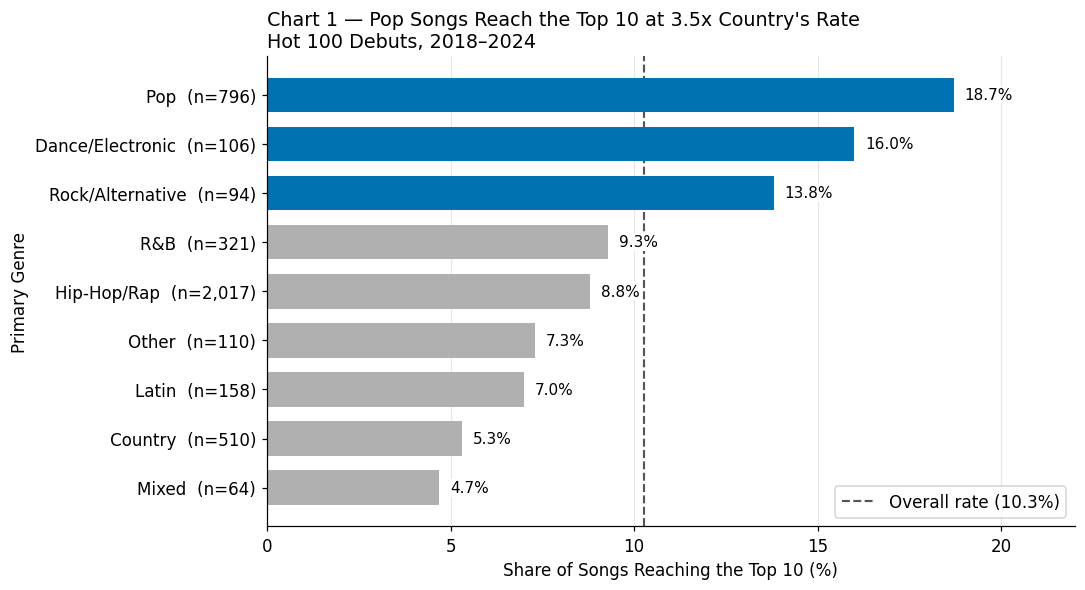

In [ ]:
# Chart 1 — Top 10 rate by genre
data = q1["summary"].sort_values("top10_rate_pct")          # already aggregated in Q1
overall = train["top10"].mean() * 100
labels = [f"{g.title()}  (n={n:,})" for g, n in zip(data.index, data["songs"])]
colours = [TOP10_COLOUR if r > overall else OTHER_COLOUR for r in data["top10_rate_pct"]]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(labels, data["top10_rate_pct"], color=colours, height=0.7, zorder=2)
ax.axvline(overall, color="#555555", linestyle="--", linewidth=1.4, zorder=1,
           label=f"Overall rate ({overall:.1f}%)")

for y, rate in enumerate(data["top10_rate_pct"]):
    ax.text(rate + 0.3, y, f"{rate:.1f}%", va="center", fontsize=10, zorder=3,
            bbox=dict(facecolor="white", edgecolor="none", pad=1))

ax.set_xlabel("Share of Songs Reaching the Top 10 (%)")
ax.set_ylabel("Primary Genre")
ax.set_title("Chart 1 — Pop Songs Reach the Top 10 at 3.5x Country's Rate\n"
             "Hot 100 Debuts, 2018–2024", fontsize=12.5, loc="left")
ax.set_xlim(0, 22)
ax.set_xticks(range(0, 21, 5))
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

**In plain English:** Pop songs reach the Top 10 about three times as often as country songs, but genre is only a modest factor.

**Interpretation.** Genre matters, but less than its reputation suggests. Pop leads at
**18.7%** and country trails at **5.3%** — a 3.5-fold spread — and the test is decisive
(p ≈ 7×10⁻¹⁶). Yet Cramér's V of **0.146** is only a *small* effect: genre shifts the
odds, it does not determine them. Note that hip-hop/rap is the **largest** genre in the
data but converts at only 8.8%, below the overall rate.

**Caveat.** Genre is not a property of the song so much as of how MusicBrainz volunteers
labelled it. 166 songs (3.1%) have no genre at all and are absent from this test, and
96 are labelled `mixed` because two genres tied on votes. Coverage is also thinner for
2026 (93.7%) than earlier years, since recent releases have had less time to be tagged.

### Q2. Does an artist's past success predict the next hit?

**Hypothesis.** H₀: prior Top 10 count is unrelated to reaching the Top 10.
H₁: artists with more prior Top 10s are likelier to do it again — through fanbase,
playlist placement and label budget, none of which reset between releases.

Every count here is of songs that debuted **strictly before** this song, so nothing
from the song's own run is used.

In [ ]:
# Q2 test: group songs by the artist's prior Top 10 count (0, 1-4, 5-9, 10+) and compare Top 10 rates.
train["prior_top10_bucket"] = pd.cut(
    train["prior_top10s"], [-1, 0, 4, 9, np.inf], labels=["0", "1-4", "5-9", "10+"]
)
q2 = chi_square(train, "prior_top10_bucket")
report(q2, "Q2: Top 10 rate by the artist's prior Top 10 count")

Q2: Top 10 rate by the artist's prior Top 10 count
--------------------------------------------------
  chi2(3) = 107.9   p = 3.14e-23   Cramer's V = 0.159 (small)
  -> REJECT the null at alpha = 0.05



,songs,top10,top10_rate_pct
prior_top10_bucket,,,
0,1476,85,5.8
1-4,1452,127,8.7
5-9,458,61,13.3
10+,907,168,18.5


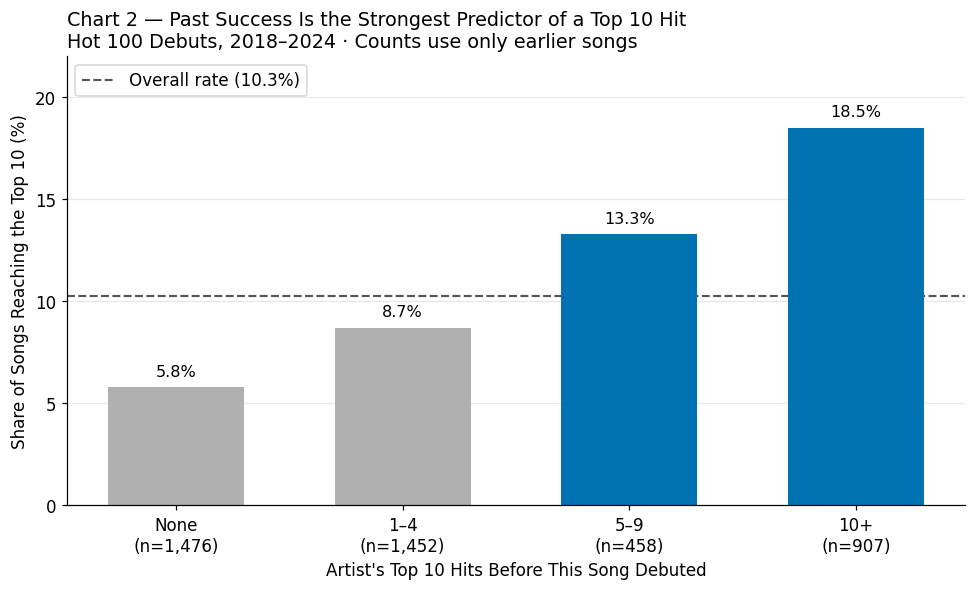

In [ ]:
# Chart 2 — Top 10 rate by the artist's prior Top 10 hits (self-contained)
train["prior_top10_bucket"] = pd.cut(
    train["prior_top10s"], [-1, 0, 4, 9, np.inf], labels=["0", "1-4", "5-9", "10+"]
)
data = (train.groupby("prior_top10_bucket", observed=True)["top10"]
             .agg(songs="size", top10="sum")
             .assign(top10_rate_pct=lambda t: (t["top10"] / t["songs"] * 100).round(1)))

overall = train["top10"].mean() * 100
names = {"0": "None", "1-4": "1–4", "5-9": "5–9", "10+": "10+"}
labels = [f"{names[str(b)]}\n(n={n:,})" for b, n in zip(data.index, data["songs"])]
colours = [TOP10_COLOUR if r > overall else OTHER_COLOUR for r in data["top10_rate_pct"]]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(labels, data["top10_rate_pct"], color=colours, width=0.6, zorder=2)
ax.axhline(overall, color="#555555", linestyle="--", linewidth=1.4, zorder=1,
           label=f"Overall rate ({overall:.1f}%)")

for x, rate in enumerate(data["top10_rate_pct"]):
    ax.text(x, rate + 0.4, f"{rate:.1f}%", ha="center", va="bottom", fontsize=10.5, zorder=3,
            bbox=dict(facecolor="white", edgecolor="none", pad=1))

ax.set_xlabel("Artist's Top 10 Hits Before This Song Debuted")
ax.set_ylabel("Share of Songs Reaching the Top 10 (%)")
ax.set_title("Chart 2 — Past Success Is the Strongest Predictor of a Top 10 Hit\n"
             "Hot 100 Debuts, 2018–2024 · Counts use only earlier songs",
             fontsize=12.5, loc="left")
ax.set_ylim(0, 22)
ax.set_yticks(range(0, 21, 5))
ax.grid(axis="x", visible=False)
ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

**In plain English:** The more hits an artist already has, the more likely their next song is a hit: about 1 in 17 for newcomers, nearly 1 in 5 for stars.

**Interpretation.** The clearest gradient in the study, and it is monotonic: **5.8%**
for artists with no prior Top 10, **8.7%** at 1-4, **13.3%** at 5-9, **18.5%** at 10 or
more. An artist with ten prior hits is **3.2 times** as likely to land another as a
newcomer (p ≈ 3×10⁻²³, V = 0.159 — the largest effect size we measure).

**Caveat.** This measures the artist, not the song, and it is partly self-fulfilling: an
established artist receives the playlist placement and marketing that *cause* the next
hit. It is a good predictor and a poor explanation, and it cannot help an unknown artist
at all — the group where a prediction would be worth the most is the group where we have
the least to say.

### Q3. Does releasing many songs at once change a song's chances?

**Hypothesis.** H₀: the number of songs an artist puts on the chart in the same week is
unrelated to the target. H₁: songs arriving together compete for the same listeners and
fall out faster, so a full album drop should lower each track's chance.

In [ ]:
# Q3 test: compare Top 10 rates by how many songs the artist debuted in the same week.
q3 = chi_square(train, "album_debut_bucket")
report(q3, "Q3: Top 10 rate by how many songs the artist debuted that week")

Q3: Top 10 rate by how many songs the artist debuted that week
--------------------------------------------------------------
  chi2(3) = 44.5   p = 1.16e-09   Cramer's V = 0.102 (small)
  -> REJECT the null at alpha = 0.05



,songs,top10,top10_rate_pct
album_debut_bucket,,,
1,2123,246,11.6
10+,1379,163,11.8
2-4,366,23,6.3
5-9,425,9,2.1


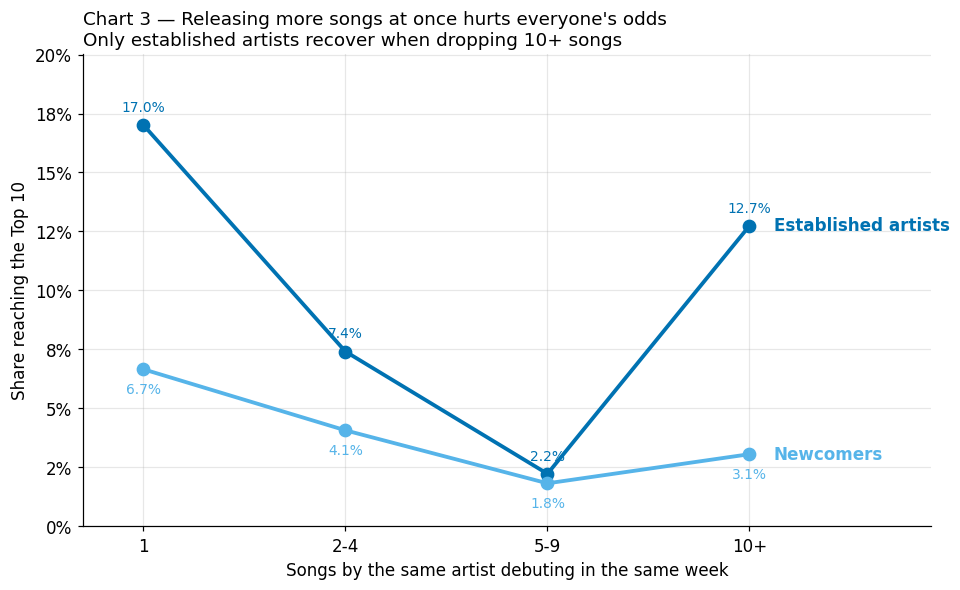

In [ ]:
# Chart 3 — Top 10 rate by album-drop size, split into newcomers vs established artists.
order = ["1", "2-4", "5-9", "10+"]
train["artist_history"] = np.where(train["prior_top10s"] > 0, "Established artists", "Newcomers")
rates = train.pivot_table(index="album_debut_bucket", columns="artist_history",
                          values="top10", aggfunc="mean").reindex(order) * 100

fig, ax = plt.subplots(figsize=(9, 5.5))
for group, colour, offset in [("Established artists", TOP10_COLOUR, 9), ("Newcomers", "#56B4E9", -16)]:
    ax.plot(order, rates[group], marker="o", linewidth=2.5, markersize=8, color=colour)
    for x, y in zip(order, rates[group]):
        ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, offset),
                    ha="center", fontsize=9, color=colour)
    ax.text(3.12, rates[group].iloc[-1], group, color=colour, va="center", fontweight="bold")

ax.set_xlim(-0.3, 3.9)
ax.set_ylim(0, rates.max().max() + 3)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
ax.set_xlabel("Songs by the same artist debuting in the same week")
ax.set_ylabel("Share reaching the Top 10")
ax.set_title("Chart 3 — Releasing more songs at once hurts everyone's odds\n"
             "Only established artists recover when dropping 10+ songs",
             fontsize=12, loc="left")
plt.tight_layout()
plt.show()

**In plain English:** Releasing many songs at once hurts each song's chances; huge 10+ song drops only look fine because they come from superstars.

**Interpretation.** Drop size matters (p ≈ 1×10⁻⁹), but the pooled pattern hides two different stories. Splitting by whether the artist already had a Top 10 shows them.

For both groups, releasing more songs at once lowers each song's odds. Established artists fall from 17.0% when a song is released alone to 7.4% in a 2-4 song drop and 2.2% in a 5-9 song drop. Newcomers follow the same path at a lower level: 6.7%, 4.1%, then 1.8%. At 5-9 songs, the gap between the groups nearly disappears. Dilution wipes out almost all of the established artist's advantage.

The recovery at ten or more songs happens only for established artists, who climb back to 12.7%. Newcomers stay low at 3.1%. So the rebound in the pooled numbers (11.8% at 10+) does not mean big drops work. It reflects who releases them: 1,248 of the 1,379 songs in that bucket come from established artists, the Drake and Taylor Swift tier, whose songs chart well regardless. Even for them, a 10+ drop still underperforms a solo release (12.7% vs 17.0%).

This is why the feature is a four-way bucket and not a boolean. A 5+ flag gave 9.0% versus 10.3%, averaging away a range that actually runs from 2.1% to 11.8%.

**Caveat.** "Prior Top 10" is a rough proxy for artist size. It puts an artist with one past hit in the same group as Drake, so the established line still mixes very different artists, and we have not held the individual artist fixed. Two newcomer points also rest on very few hits: about two songs at 5-9 (n=110) and about four at 10+ (n=131). Those rates are suggestive, not firm. The honest reading stays conditional: for a given artist, putting a song in a mid-sized album drop looks costly, and only artists who already have a track record seem to escape that penalty at large drop sizes.

### Q4. Do the lyrics of Top 10 songs differ measurably?

**Hypothesis.** H₀: lyric measures are distributed identically in both groups.
H₁: hits are more repetitive and use a smaller vocabulary — the "catchiness" claim.

 **Unique Word Ratio:** A short example, the lyric "baby baby baby oh" has 4 words but only 2 different ones ("baby" and "oh"), so its ratio is 2 ÷ 4 = 0.5. A line where every word is different would score 1.0.

In [ ]:
# Q4 test: compare four lyric measures between hits and non-hits.
lyric_cols = ["word_count", "unique_word_ratio", "repetition_score", "avg_line_length"]
rows = []
for col in lyric_cols:
    r = mann_whitney(train, col)
    rows.append({
        "feature": col,
        "median_top10": round(r["median_top10"], 3),
        "median_other": round(r["median_other"], 3),
        "difference": round(r["median_top10"] - r["median_other"], 3),
        "p_value": f"{r['p']:.3g}",
        "significant": "yes" if r["p"] < ALPHA else "no",
    })
q4 = pd.DataFrame(rows).set_index("feature")
print(f"Mann-Whitney U, n = {r['n_top10']} Top 10 vs {r['n_other']:,} others "
      "(songs with lyrics only)\n")
display(q4)

Mann-Whitney U, n = 439 Top 10 vs 3,835 others (songs with lyrics only)



,median_top10,median_other,difference,p_value,significant
feature,,,,,
word_count,433.000,422.000,11.000,0.0734,no
unique_word_ratio,0.348,0.361,-0.012,9.68e-05,yes
repetition_score,0.418,0.407,0.011,0.162,no
avg_line_length,7.850,7.860,-0.010,0.155,no


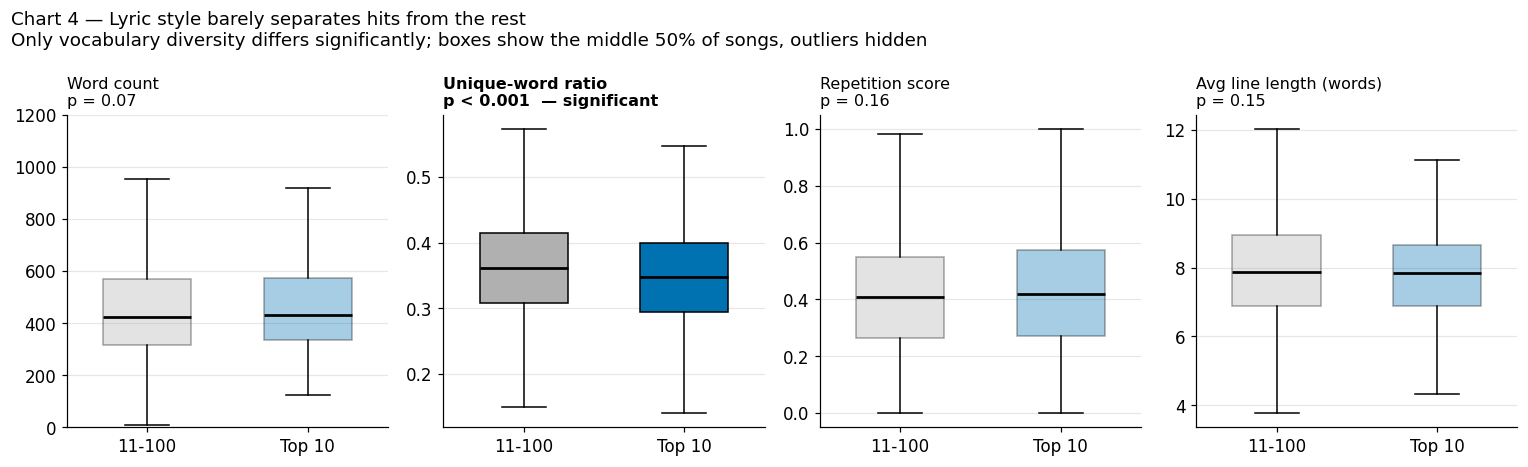

In [ ]:
# Chart 4 — box plots of the four lyric measures, hits vs non-hits.
titles = {"word_count": "Word count", "unique_word_ratio": "Unique-word ratio",
          "repetition_score": "Repetition score", "avg_line_length": "Avg line length (words)"}

fig, axes = plt.subplots(1, 4, figsize=(14, 4.3))
for ax, col in zip(axes, lyric_cols):
    sig = q4.loc[col, "significant"] == "yes"
    p = float(q4.loc[col, "p_value"])
    parts = ax.boxplot([train.loc[~train["top10"], col].dropna(), train.loc[train["top10"], col].dropna()],
                       tick_labels=["11-100", "Top 10"], patch_artist=True, widths=0.55,
                       showfliers=False, medianprops=dict(color="black", lw=1.8))
    for box, colour in zip(parts["boxes"], [OTHER_COLOUR, TOP10_COLOUR]):
        box.set_facecolor(colour)
        box.set_alpha(1 if sig else 0.35)
    ax.set_title(f"{titles[col]}\n{'p < 0.001' if p < 0.001 else f'p = {p:.2f}'}"
                 f"{'  — significant' if sig else ''}",
                 fontsize=10.5, loc="left", fontweight="bold" if sig else "normal")
    ax.grid(axis="x", visible=False)
axes[0].set_ylim(0, 1200)

fig.suptitle("Chart 4 — Lyric style barely separates hits from the rest\n"
             "Only vocabulary diversity differs significantly; boxes show the middle 50% of songs, outliers hidden",
             fontsize=12, x=0.01, ha="left")
plt.tight_layout()
plt.show()

**In plain English:** On these four lyric measures, hits and non-hits look almost the same.

**Interpretation.** Largely a null result, and worth stating plainly. Of four measures
only **unique-word ratio** differs significantly (0.348 vs 0.361, p ≈ 9.7×10⁻⁵): Top 10
songs use a *slightly* narrower vocabulary, consistent with the catchiness story but far
too small to act on. Word count (433 vs 422, p = 0.073), repetition (0.418 vs 0.407,
p = 0.162) and line length (7.85 vs 7.86, p = 0.155) show nothing. The boxes overlap
almost completely.

**Caveat.** These are measures of *form*, not content — they count words without
reading them. A song about heartbreak and a song about money score identically. The
honest conclusion is that **these** lyric features are weak, not that lyrics are
irrelevant; sentiment or topic modelling could still find something. 109 songs carry
`lyrics_suspect_short`, and 32 have no lyrics at all and are excluded rather than
counted as zero.

### Q5. Is there a seasonal release window for hits?

**Hypothesis.** H₀: the debut month is unrelated to the target. H₁: some months are
better — the industry's received wisdom about spring and pre-holiday release slots.

This question doubles as a test of Q3: if album drops drive the target, and superstars
schedule albums in particular months, then any "month effect" may be an artist-schedule
effect wearing a disguise.

In [ ]:
# Q5 test: Top 10 rate by debut month, first for all songs, then without big album drops.
q5_all = chi_square(train, "debut_month")
report(q5_all, "Q5a: Top 10 rate by debut month — ALL songs")

no_bomb = train[train["album_debut_bucket"].isin(["1", "2-4"])]
q5_nb = chi_square(no_bomb, "debut_month")
report(q5_nb, "Q5b: the same test, EXCLUDING drops of 5+ songs")

Q5a: Top 10 rate by debut month — ALL songs
-------------------------------------------
  chi2(11) = 25.0   p = 0.00915   Cramer's V = 0.076 (negligible)
  -> REJECT the null at alpha = 0.05



,songs,top10,top10_rate_pct
debut_month,,,
1,288,26,9.0
2,300,26,8.7
3,355,25,7.0
4,361,39,10.8
5,392,59,15.1
6,370,36,9.7
7,414,36,8.7
8,360,34,9.4
9,352,34,9.7


Q5b: the same test, EXCLUDING drops of 5+ songs
-----------------------------------------------
  chi2(11) = 5.5   p = 0.906   Cramer's V = 0.047 (negligible)
  -> cannot reject the null at alpha = 0.05



,songs,top10,top10_rate_pct
debut_month,,,
1,213,22,10.3
2,224,22,9.8
3,213,19,8.9
4,221,25,11.3
5,189,27,14.3
6,235,28,11.9
7,215,20,9.3
8,226,26,11.5
9,185,17,9.2


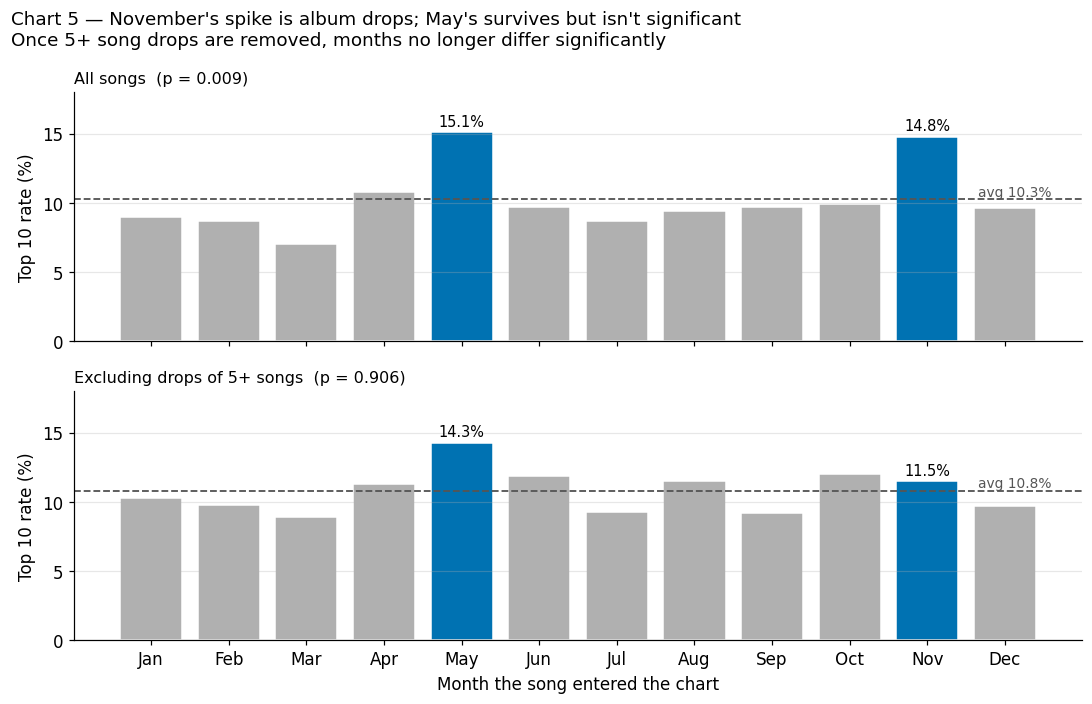

In [ ]:
# Chart 5 — Top 10 rate by month, with and without big album drops.
labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
panels = [("All songs", q5_all, train), ("Excluding drops of 5+ songs", q5_nb, no_bomb)]

fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True, sharey=True)
for ax, (name, result, data) in zip(axes, panels):
    rate = result["summary"]["top10_rate_pct"].reindex(range(1, 13))
    avg = data["top10"].mean() * 100
    colours = [TOP10_COLOUR if m in (5, 11) else OTHER_COLOUR for m in rate.index]
    bars = ax.bar(labels, rate, color=colours, edgecolor="white")
    ax.bar_label(bars, labels=[f"{v:.1f}%" if m in (5, 11) else "" for m, v in rate.items()],
                 fontsize=9.5, padding=2)
    ax.axhline(avg, color="#555555", linestyle="--", linewidth=1.2)
    ax.text(11.6, avg, f"avg {avg:.1f}%", va="bottom", ha="right", fontsize=9, color="#555555")
    ax.set_title(f"{name}  (p = {result['p']:.3f})", fontsize=10.5, loc="left")
    ax.set_ylabel("Top 10 rate (%)")
    ax.set_ylim(0, 18)
    ax.grid(axis="x", visible=False)

axes[1].set_xlabel("Month the song entered the chart")
fig.suptitle("Chart 5 — November's spike is album drops; May's survives but isn't significant\n"
             "Once 5+ song drops are removed, months no longer differ significantly",
             fontsize=12, x=0.01, ha="left")
plt.tight_layout()
plt.show()

**In plain English:** The apparent "best months" mostly came from superstar album weeks; once those are removed, no month is significantly better.

**Interpretation.** At first, a month effect appears real: p = 0.009 across all songs, with May at 15.1% and November at 14.8% against an overall 10.3%. Removing drops of five or more songs makes the overall pattern disappear (p = 0.906, V = 0.047). The two peaks behave differently, though. November falls to 11.5%, close to the new 10.8% average, so its spike was Taylor Swift's 2021-11-27 re-release. May barely moves (14.3%). Three of the four largest release weeks were in May: Drake (40 songs, 2026-05-30), Taylor Swift (31, 2024-05-04) and Morgan Wallen (29, 2025-05-31). But May was already high without them. With only 189 songs left in May and no significant overall test, that remaining bump looks like chance, not a release season.

**Caveat.** This confounder was found by luck rather than design. We only tested it because Q3 gave us a reason to suspect it, and other confounders of the same shape may still be in the data. Removing big drops also cuts about 40% of the songs, so part of the jump in p-value is lost statistical power.

### Q6. Do featured artists help?

**Hypothesis.** H₀: a "Featuring" credit is unrelated to the target. H₁: a feature adds
a second fanbase, so it should raise the chance. *(Table only — two numbers.)*

In [ ]:
# Q6 test: songs with vs without a featured artist, and whether a bigger guest helps.
q6 = chi_square(train, "has_feature")
report(q6, "Q6: Top 10 rate with and without a featured artist")

print("Does it help to feature someone bigger than yourself?")
featured = train[train["has_feature"]].copy()
featured["guest_bigger"] = featured["best_prior_top10s"] > featured["prior_top10s"]
display(
    featured.groupby("guest_bigger")
            .agg(songs=("title", "size"), top10=("top10", "sum"))
            .assign(top10_rate_pct=lambda t: (t["top10"] / t["songs"] * 100).round(1))
)

Q6: Top 10 rate with and without a featured artist
--------------------------------------------------
  chi2(1) = 0.5   p = 0.494   Cramer's V = 0.010 (negligible)
  -> cannot reject the null at alpha = 0.05



,songs,top10,top10_rate_pct
has_feature,,,
False,3417,357,10.4
True,876,84,9.6


Does it help to feature someone bigger than yourself?


,songs,top10,top10_rate_pct
guest_bigger,,,
False,488,52,10.7
True,388,32,8.2


**In plain English:** Having a featured artist makes no difference to the odds.

**Interpretation.** No association. Songs with a featured artist reach the Top 10 at
**9.6%**, against **10.4%** without one (p = 0.494, V = 0.010). Featuring someone with a bigger
chart record than the lead artist does not help either: **8.2%** when the guest has more prior
Top 10s, against **10.7%** otherwise (shown as a table, not tested separately).

**Caveat.** Features are not assigned at random. Smaller artists are the ones most likely to
recruit a bigger guest, so the second comparison partly reflects the lead artist's size. Only the
debut-week credit counts, so artists added to a remix after the song charted are not treated as
features.


### Q7. Is explicit language associated with hits?

**Hypothesis.** H₀: profanity is unrelated to the target. H₁: explicit songs face radio
restrictions, which should lower their chance. *(Table only.)*

In [ ]:
# Q7 test: explicit vs clean lyrics, plus how common profanity is in each genre.
q7 = chi_square(train, "has_profanity")
report(q7, "Q7: Top 10 rate by whether the lyrics contain strong profanity")

print("Profanity is really a genre marker:")
display(
    train.dropna(subset=["has_profanity", "primary_genre"])
         .groupby("primary_genre")["has_profanity"].mean().mul(100).round(1)
         .sort_values(ascending=False).rename("profanity_rate_pct").to_frame()
)

Q7: Top 10 rate by whether the lyrics contain strong profanity
--------------------------------------------------------------
  chi2(1) = 0.1   p = 0.714   Cramer's V = 0.006 (negligible)
  -> cannot reject the null at alpha = 0.05



,songs,top10,top10_rate_pct
has_profanity,,,
False,1946,204,10.5
True,2328,235,10.1


Profanity is really a genre marker:


,profanity_rate_pct
primary_genre,
hip-hop/rap,85.8
R&B,53.9
dance/electronic,38.7
rock/alternative,28.7
Latin,26.6
pop,25.5
mixed,25.0
other,8.4
country,7.9


**In plain English:** Explicit lyrics make no difference to the odds.

**Interpretation.** No association: **10.1%** for explicit songs against **10.5%** for
clean ones (p = 0.714, V = 0.006). The radio-restriction hypothesis is not supported in
the streaming era, which is plausible — chart position is now driven by streams, where
an explicit tag costs nothing.

**Caveat.** The flag is a keyword list applied to a transcription, so it inherits
LRCLIB's censoring conventions; a song transcribed with asterisks may be missed. More
importantly the variable is close to a genre proxy — profanity rates run far higher in
hip-hop/rap than in country — so it carries little information of its own.

### Q8. Do hits chart sooner after release?

**Hypothesis.** H₀: the gap between release and chart debut is the same for both groups.
H₁: hits chart immediately on release-week streaming, while slower songs build gradually.
*(Table only.)*

In [ ]:
# Q8 test: days between a song's release and its chart debut, hits vs non-hits.
q8 = mann_whitney(train, "days_release_to_chart")
print("Q8: days from first release to chart debut\n" + "-" * 44)
print(f"  Top 10 median   {q8['median_top10']:.0f} days   (n = {q8['n_top10']})")
print(f"  others median   {q8['median_other']:.0f} days   (n = {q8['n_other']:,})")
print(f"  Mann-Whitney U = {q8['u']:.0f}   p = {q8['p']:.3g}   "
      f"-> {'significant' if q8['p'] < ALPHA else 'not significant'}\n")

display(
    train.groupby("top10")["days_release_to_chart"]
         .describe(percentiles=[0.25, 0.5, 0.75])[["count", "25%", "50%", "75%", "mean"]]
         .round(1)
         .rename(index={True: "Top 10", False: "peaked 11-100"})
)

Q8: days from first release to chart debut
--------------------------------------------
  Top 10 median   15 days   (n = 377)
  others median   15 days   (n = 3,521)
  Mann-Whitney U = 585672   p = 4.96e-05   -> significant



,count,25%,50%,75%,mean
top10,,,,,
peaked 11-100,3521.0,15.0,15.0,25.0,182.1
Top 10,377.0,15.0,15.0,16.0,140.9


**In plain English:** Most songs chart about two weeks after release either way; songs that take months to chart are the ones that rarely become hits.

**Interpretation.** A case where the test and the headline number disagree, and the
disagreement is the point. Both groups have a median of **15 days**, yet Mann-Whitney
returns p ≈ 5×10⁻⁵. The test compares whole distributions, not medians: the groups are
identical at the median and diverge in the upper tail, where non-hits have a 75th
percentile of **25 days** against **16** for hits. A long slow burn to the chart is a
non-hit pattern; hits arrive on schedule.

**Caveat.** Reporting "medians are equal, p < 0.001" without this explanation would be
actively misleading. The mean is useless here — 141 vs 182 days — because catalogue
reissues give some songs release dates decades before their chart run. 395 songs are
excluded because MusicBrainz knows only the release *year*.

### Q9. Has the genre mix of the Top 10 shifted since 2018?

**Hypothesis.** H₀: the genre composition of Top 10 songs is stable year to year.
H₁: it has shifted — the project brief asks how hits changed over time. *(Table only.)*

In [ ]:
# Q9 test: did the genre mix of Top 10 songs change from year to year?
hits = train[train["top10"]].dropna(subset=["primary_genre"])
mix = pd.crosstab(hits["debut_year"], hits["primary_genre"])
chi2, p, dof, _ = stats.chi2_contingency(mix)
print("Q9: genre composition of Top 10 songs by debut year\n" + "-" * 52)
print(f"  chi2({dof}) = {chi2:.1f}   p = {p:.3g}   "
      f"-> {'composition changed' if p < ALPHA else 'no detectable change'}\n")

share = (pd.crosstab(hits["debut_year"], hits["primary_genre"], normalize="index") * 100).round(1)
display(share[["hip-hop/rap", "pop", "country", "R&B"]])

Q9: genre composition of Top 10 songs by debut year
----------------------------------------------------
  chi2(48) = 82.9   p = 0.00131   -> composition changed



primary_genre,hip-hop/rap,pop,country,R&B
debut_year,,,,
2018,56.7,26.9,0.0,6.0
2019,27.7,53.2,2.1,4.3
2020,45.3,39.1,4.7,1.6
2021,42.6,27.9,3.3,16.4
2022,37.7,31.2,9.1,5.2
2023,35.1,29.8,12.3,3.5
2024,36.5,36.5,11.1,11.1


**In plain English:** Between 2018 and 2024, hip-hop's share of Top 10 hits fell and country's rose.

**Interpretation.** The mix has changed (p = 0.0013). Hip-hop/rap's share of Top 10
songs fell from **56.7%** in 2018 to **36.5%** in 2024, while country rose from **0.0%**
to **11.1%** over the same period — country was entirely absent from the 2018 Top 10 in
these data. Pop is volatile rather than trending, swinging between 26.9% and 53.2%.

**Caveat.** These are shares of a small annual numerator — roughly 50-70 Top 10 songs a
year — so single-year moves are noisy, and the 2019 pop spike rests on few songs. The
direction over the full period is more trustworthy than any one year. Genre labels also
come from volunteer tagging that may itself have shifted over time.

### Q10. Does debut position predict the final peak — or is the question circular?

**Hypothesis.** H₀: debut position is unrelated to reaching the Top 10.
H₁: a strong debut predicts a strong peak.

We include this question because it is a trap, and because falling into it is instructive.
*(Table only.)*

In [ ]:
# Q10, naive version: Top 10 rate by debut position (this shows the leakage problem).
print("The naive answer\n" + "-" * 44)
naive = train.copy()
naive["debut_bucket"] = pd.cut(naive["debut_position"], [0, 10, 25, 50, 75, 100],
                               labels=["1-10", "11-25", "26-50", "51-75", "76-100"])
display(
    naive.groupby("debut_bucket", observed=True)
         .agg(songs=("title", "size"), top10=("top10", "sum"))
         .assign(top10_rate_pct=lambda t: (t["top10"] / t["songs"] * 100).round(1))
)

debuted_inside = train[train["debut_position"] <= 10]
print(f"\nSongs debuting at positions 1-10: {len(debuted_inside)}")
print(f"  of which reached the Top 10: {debuted_inside['top10'].sum()} "
      f"({debuted_inside['top10'].mean()*100:.0f}%)")
print("  ^ this is a DEFINITION, not a finding: 'top10' means the song ever")
print("    held a position in 1-10, so debuting there already satisfies it.")

The naive answer
--------------------------------------------


,songs,top10,top10_rate_pct
debut_bucket,,,
1-10,303,303,100.0
11-25,435,29,6.7
26-50,775,37,4.8
51-75,1098,28,2.6
76-100,1682,44,2.6



Songs debuting at positions 1-10: 303
  of which reached the Top 10: 303 (100%)
  ^ this is a DEFINITION, not a finding: 'top10' means the song ever
    held a position in 1-10, so debuting there already satisfies it.


In [ ]:
# Q10, honest version: only songs that debuted outside the Top 10.
print("The honest answer — songs that debuted at 11 or below\n" + "-" * 54)
outside = train[train["debut_position"] > 10].copy()
outside["debut_bucket"] = pd.cut(outside["debut_position"], [10, 25, 50, 75, 100],
                                 labels=["11-25", "26-50", "51-75", "76-100"])
q10 = chi_square(outside, "debut_bucket")
report(q10, "Q10: climbing into the Top 10 from outside it")

The honest answer — songs that debuted at 11 or below
------------------------------------------------------
Q10: climbing into the Top 10 from outside it
---------------------------------------------
  chi2(3) = 23.7   p = 2.86e-05   Cramer's V = 0.077 (negligible)
  -> REJECT the null at alpha = 0.05



,songs,top10,top10_rate_pct
debut_bucket,,,
11-25,435,29,6.7
26-50,775,37,4.8
51-75,1098,28,2.6
76-100,1682,44,2.6


**In plain English:** Debuting in the Top 10 makes a song a Top 10 song by definition, so we only count songs that climbed in; starting higher helps, but only a little.

**Interpretation.** The naive table shows a **100%** Top 10 rate for songs debuting at
positions 1-10, which looks like the strongest predictor in the study and is in fact
pure **target leakage**: `top10` is defined as ever occupying positions 1-10, so a song
debuting there has already met the definition. Any model given `debut_position` would
score superbly and have learned nothing.

Excluding those 303 songs gives the real answer. Among songs debuting at 11 or below,
climbing into the Top 10 still depends on where they start — **6.7%** from 11-25 down to
**2.6%** from 76-100 (p ≈ 2.9×10⁻⁵) — but the effect is small (V = 0.077), far weaker
than prior artist success.

**Caveat.** The leak here is obvious once seen. The general lesson is that a feature
recorded during the outcome window needs checking against the target's *definition*, not
just its timing, and that a suspiciously excellent predictor deserves suspicion first.

**So what:** of ten hypotheses, four hold up (genre, artist history, release strategy,
genre drift over time), three are null results worth reporting (lyric style, features,
profanity), and three only became interpretable after a confounder or a definition was
pinned down.

## 5. Conclusion

### 5.1 Prioritised insights

Ranked by expected impact against the effort to act on them.

| # | Insight | Evidence | Impact | Feasibility | Verdict |
|---|---|---|---|---|---|
| 1 | **Release strategy is the biggest controllable lever.** A song released alone reaches the Top 10 at 11.6%; buried in a 5-9 track drop, 2.1% | Q3, p ≈ 1×10⁻⁹ | **High** — a 5x swing | **High** — scheduling is a decision, not a talent | **Act on it.** Stagger singles instead of dropping mid-sized albums whole |
| 2 | **Artist track record is the strongest predictor, and it is not actionable.** 18.5% for 10+ prior hits vs 5.8% for none | Q2, V = 0.159 | **High** — best single predictor | **Low** — cannot be changed for a given artist | **Use for forecasting, not strategy.** Essential in any model; useless as advice |
| 3 | **Genre shifts the odds by roughly 3.5x.** Pop 18.7%, country 5.3% | Q1, p ≈ 7×10⁻¹⁶ | **Medium** — real but V = 0.146 | **Low** — an artist cannot switch genre on request | **Use as a baseline adjustment,** not a target |
| 4 | **Lyric style carries almost no signal.** Only vocabulary diversity differs, 0.348 vs 0.361 | Q4, 3 of 4 tests null | **Medium** — a negative result that redirects effort | **High** — stop here cheaply | **Do not invest further in surface lyric metrics.** Test sentiment or topic instead |
| 5 | **Two "findings" were artefacts.** The May/November "season" did not survive removing large album drops; debut position was target leakage | Q5, Q10 | **High** — both would have shipped a wrong claim | **High** — costs one extra test each | **Adopt the habit:** re-test any effect that could be explained by who released the song |

### 5.2 Risks and limitations

**Data and licensing.** The Billboard archive repository declares **no licence**, and
LRCLIB publishes none on its public docs page; only MusicBrainz is explicitly CC0. Chart
compilations and lyrics are both copyrighted. This work is non-commercial academic
analysis and the raw lyrics should not be redistributed.

**Coverage that is not random.** 166 songs (3.1%) have no genre, and coverage is worst
for 2026 (93.7%) because recent releases are less tagged — so the most recent year is
also the least complete. 54 songs are missing MusicBrainz data entirely, mostly
initialism titles ("B.I.T.C.H.", "1.5") that defeat the search. Missingness correlates
with title style, which is not random.

**Measurement.** Genre comes from volunteer tagging, not a taxonomy. 96 songs are
`mixed` because two genres tied. The profanity flag is a keyword list. 109 songs carry
`lyrics_suspect_short` and their lyric features may understate the real text.

**Design.** The target is a threshold on a continuous outcome: a song peaking at 11 is
counted with one peaking at 100. Nine years is nine observations of any yearly trend.
Album-drop size is confounded with artist size and we cannot fully separate them.
And crucially, **everything here is association, not causation** — nothing was randomised.

**What would change our conclusions.** If playlist and marketing-spend data were
available, we would expect much of the "artist history" effect to be absorbed by them,
since those are the mechanism rather than the cause.

### 5.3 Next steps

1. **Fit a baseline model** on the 2018-2024 training split — logistic regression with
   prior Top 10s, genre, album-drop bucket — and evaluate once on the held-out
   2025-2026 songs. Report precision and recall at a useful threshold, not accuracy: a
   model predicting "never" is 90% accurate and worthless.
2. **Test lyric content, not lyric form.** Sentiment and topic features, since Q4 rules
   out the surface measures rather than lyrics as a whole.
3. **Separate artist size from release strategy** using artist fixed effects, which would
   turn Q3 from an association into something closer to a recommendation.
4. **Re-run the genre pull for 2026** later in the year, once tagging catches up, and
   re-check whether the coverage gap moved any conclusion.
5. **Add the dropped 54 songs** by matching on ISRC rather than title text.

**So what:** the actionable finding is about *how* a song is released; the strongest
predictive finding is about *who* released it; and the lyric hypothesis that motivated
the project does not survive contact with the data.

## 6. References

**Data sources**

1. Hollingshead, M. *Billboard Hot 100 archive* — JSON files for every Billboard Hot 100
   chart, 1958-2026. https://github.com/mhollingshead/billboard-hot-100 (accessed
   September 2026). No licence declared by the repository.
2. *LRCLIB* — open lyrics database and API. https://lrclib.net/docs (accessed September
   2026). No licence stated on the public documentation page.
3. *MusicBrainz* — open music encyclopedia; recordings, release groups and artists.
   https://musicbrainz.org/doc/MusicBrainz_API (accessed September 2026). Core data
   released under CC0; see https://musicbrainz.org/doc/About/Data_License.

**Software**

4. McKinney, W. (2010). Data structures for statistical computing in Python. *pandas*.
5. Harris, C. R. et al. (2020). Array programming with NumPy. *Nature* 585, 357-362.
6. Virtanen, P. et al. (2020). SciPy 1.0: fundamental algorithms for scientific
   computing in Python. *Nature Methods* 17, 261-272.
7. Hunter, J. D. (2007). Matplotlib: a 2D graphics environment. *Computing in Science &
   Engineering* 9(3), 90-95.
8. Bachmann, M. *RapidFuzz* — fast fuzzy string matching.
   https://github.com/rapidfuzz/RapidFuzz (used in the collection scripts).

**Method**

9. Cramér, H. (1946). *Mathematical Methods of Statistics*. Princeton University Press.
   (Cramér's V, used throughout as the effect size alongside chi-square.)
10. Mann, H. B. & Whitney, D. R. (1947). On a test of whether one of two random variables
    is stochastically larger than the other. *Annals of Mathematical Statistics* 18(1),
    50-60.

**Project code.** Collection and cleaning scripts are in `scripts/` (`01_billboard.py`
through `08_features.py`); every column in the analysis file is documented in
`docs/data_dictionary.md`.

**So what:** every number in this notebook traces to a documented source or a script in
this repository, so any claim here can be checked rather than taken on trust.

## 7. AI usage disclosure

Our team used Claude as the primary AI assistant for this project. Through the Claude Code extension in VS Code, we used it to draft and debug Python code for data cleaning, explain statistical functions, and refine written descriptions in this Colab notebook. All AI-generated code and text were independently reviewed by our team. We tested each script, corrected logical errors, and modified the code as needed to ensure that it accurately reflected our data and intended analysis. We also revised AI-assisted explanations to match our own interpretation of the results. To verify the statistical results, we independently recalculated key metrics directly from the raw source data and compared those values with the outputs, tables, and charts produced in the notebook. We then checked that our written interpretations and conclusions were consistent with these verified results.
